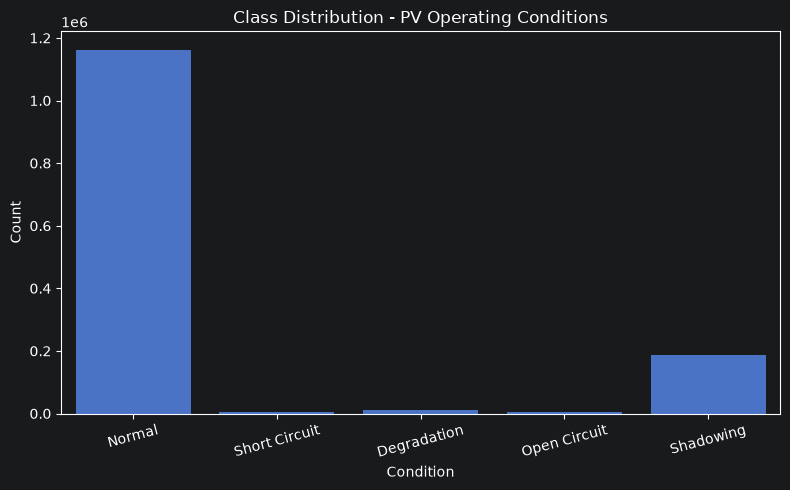

In [10]:
# class distribution
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_pv_dataset

df = load_pv_dataset()

fault_labels = {
    0: 'Normal',
    1: 'Short Circuit',
    2: 'Degradation',
    3: 'Open Circuit',
    4: 'Shadowing'
}
df['fault_label'] = df['fault'].map(fault_labels)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fault_label', order=fault_labels.values())
plt.title('Class Distribution - PV Operating Conditions')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png')
plt.show()

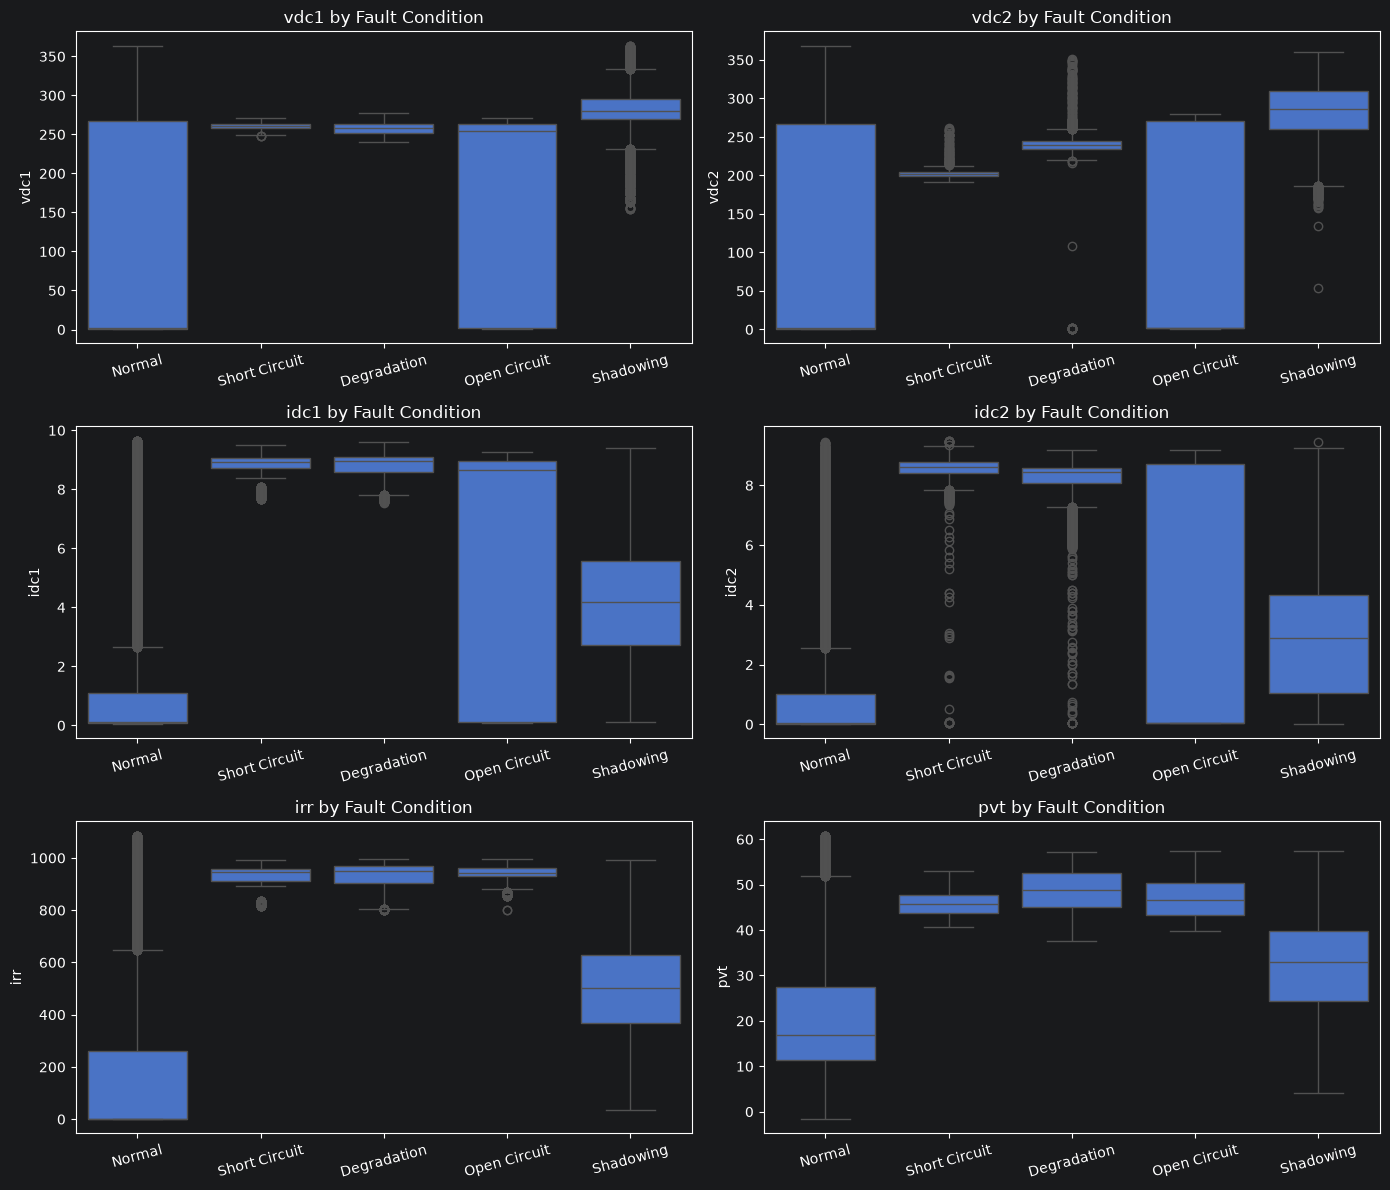

In [11]:
# feature distribution
features = ['vdc1', 'vdc2', 'idc1', 'idc2', 'irr', 'pvt']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='fault_label', y=feature, order=fault_labels.values(), ax=axes[i])
    axes[i].set_title(f'{feature} by Fault Condition')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../reports/figures/feature_boxplots.png')
plt.show()

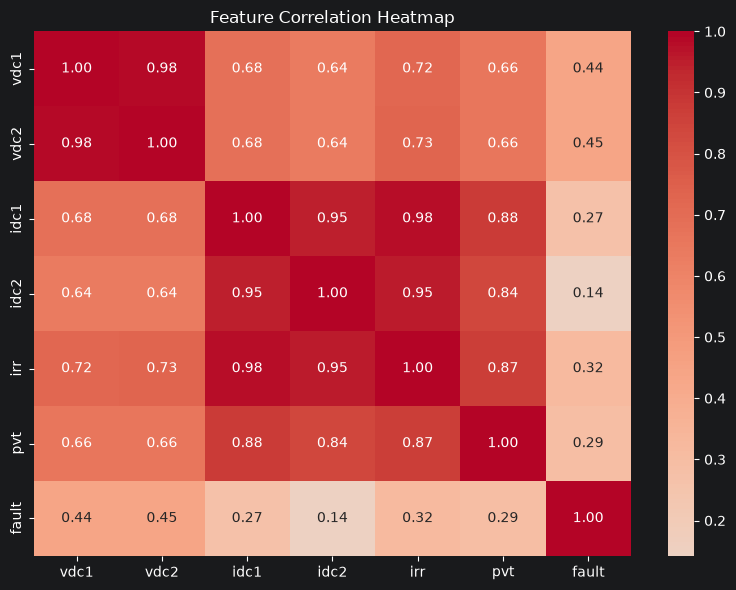

In [12]:
# correlation analysis
plt.figure(figsize=(8, 6))
correlation_matrix = df[features + ['fault']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

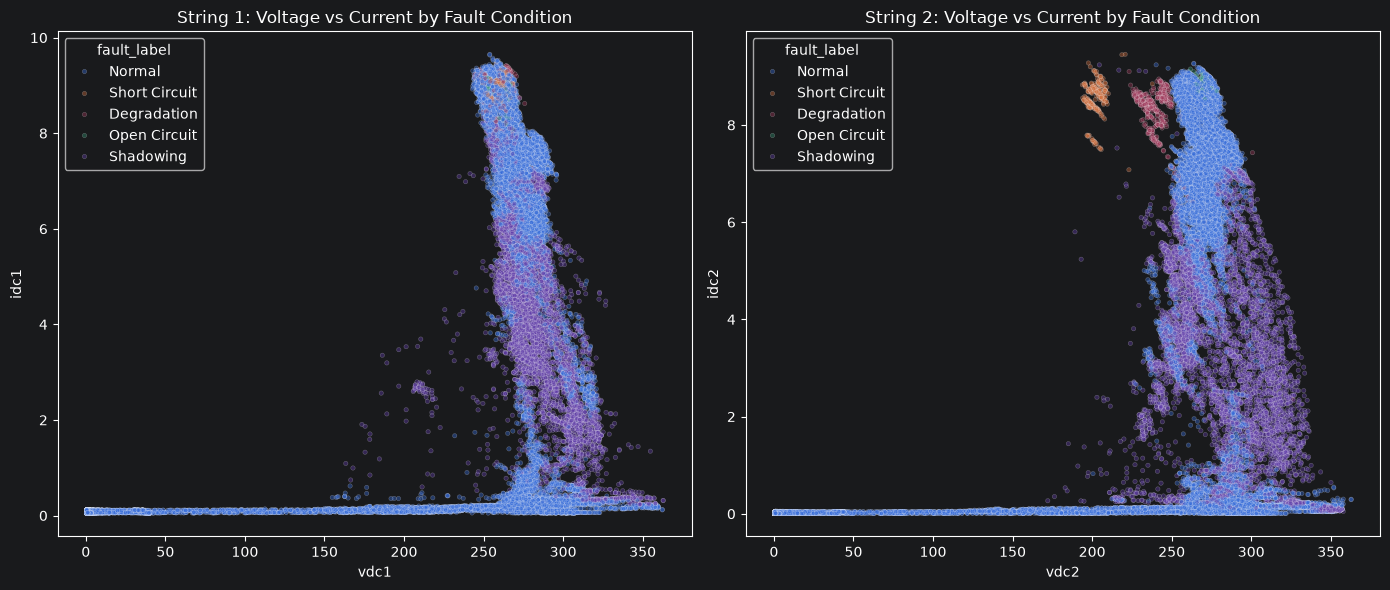

In [13]:
# voltage-current relationship
# for sample 50000 rather than complete 1.37M data rows
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df.sample(50000, random_state=42), x='vdc1', y='idc1',
                 hue='fault_label', hue_order=fault_labels.values(),
                 alpha=0.4, s=10, ax=axes[0])
axes[0].set_title('String 1: Voltage vs Current by Fault Condition')

sns.scatterplot(data=df.sample(50000, random_state=42), x='vdc2', y='idc2',
                 hue='fault_label', hue_order=fault_labels.values(),
                 alpha=0.4, s=10, ax=axes[1])
axes[1].set_title('String 2: Voltage vs Current by Fault Condition')

plt.tight_layout()
plt.savefig('../reports/figures/voltage_current_scatter.png')
plt.show()

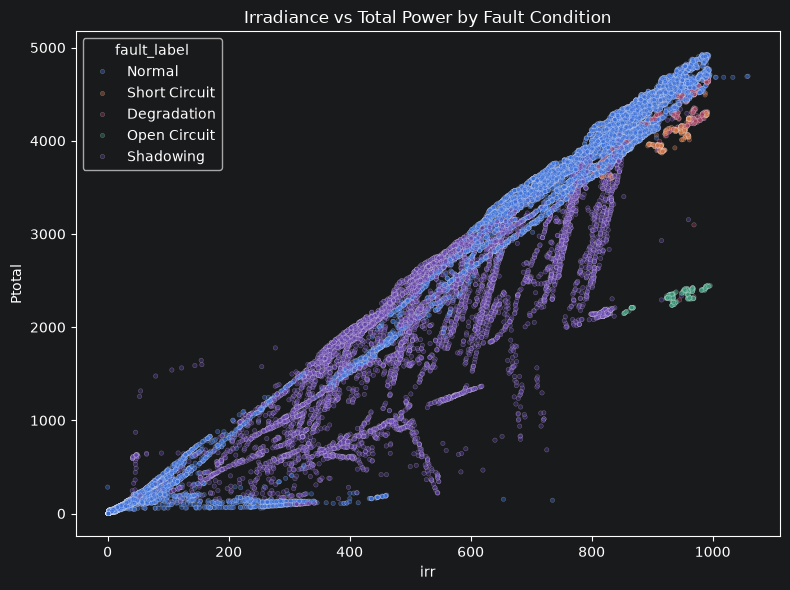

In [14]:
# power and irradiance curve
df['P1'] = df['vdc1'] * df['idc1']
df['P2'] = df['vdc2'] * df['idc2']
df['Ptotal'] = df['P1'] + df['P2']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(50000, random_state=42), x='irr', y='Ptotal',
                 hue='fault_label', hue_order=fault_labels.values(),
                 alpha=0.4, s=10)
plt.title('Irradiance vs Total Power by Fault Condition')
plt.tight_layout()
plt.savefig('../reports/figures/irradiance_power_scatter.png')
plt.show()

In [15]:
# Fault-wise summary statistics table

summary_table = df.groupby('fault_label')[features].agg(['mean', 'std']).round(2)
print(summary_table)
summary_table.to_csv('../reports/results/fault_wise_summary.csv')

                 vdc1            vdc2          idc1        idc2           irr  \
                 mean     std    mean     std  mean   std  mean   std    mean   
fault_label                                                                     
Degradation    257.88    6.39  239.82   15.27  8.82  0.41  8.22  0.77  932.33   
Normal         109.21  131.70  108.94  131.53  1.87  3.15  1.77  3.08  204.83   
Open Circuit   157.72  126.89  109.19  131.82  5.37  4.28  3.51  4.27  941.91   
Shadowing      283.50   20.91  286.67   31.46  4.14  2.00  2.83  1.92  502.89   
Short Circuit  260.93    4.16  202.28    5.13  8.84  0.38  8.51  0.57  929.46   

                         pvt         
                  std   mean    std  
fault_label                          
Degradation     51.20  48.85   4.95  
Normal         347.01  20.82  13.84  
Open Circuit    32.98  46.80   3.88  
Shadowing      184.24  31.91  10.62  
Short Circuit   42.37  46.01   3.07  


In [16]:
# Class imbalance with percentage
class_counts = df['fault_label'].value_counts()
class_percent = df['fault_label'].value_counts(normalize=True) * 100
imbalance_summary = pd.DataFrame({'count': class_counts, 'percentage': class_percent.round(2)})
print(imbalance_summary)
imbalance_summary.to_csv('../reports/results/class_imbalance_summary.csv')

                 count  percentage
fault_label                       
Normal         1162931       84.65
Shadowing       188473       13.72
Degradation      10371        0.75
Open Circuit      6024        0.44
Short Circuit     5999        0.44


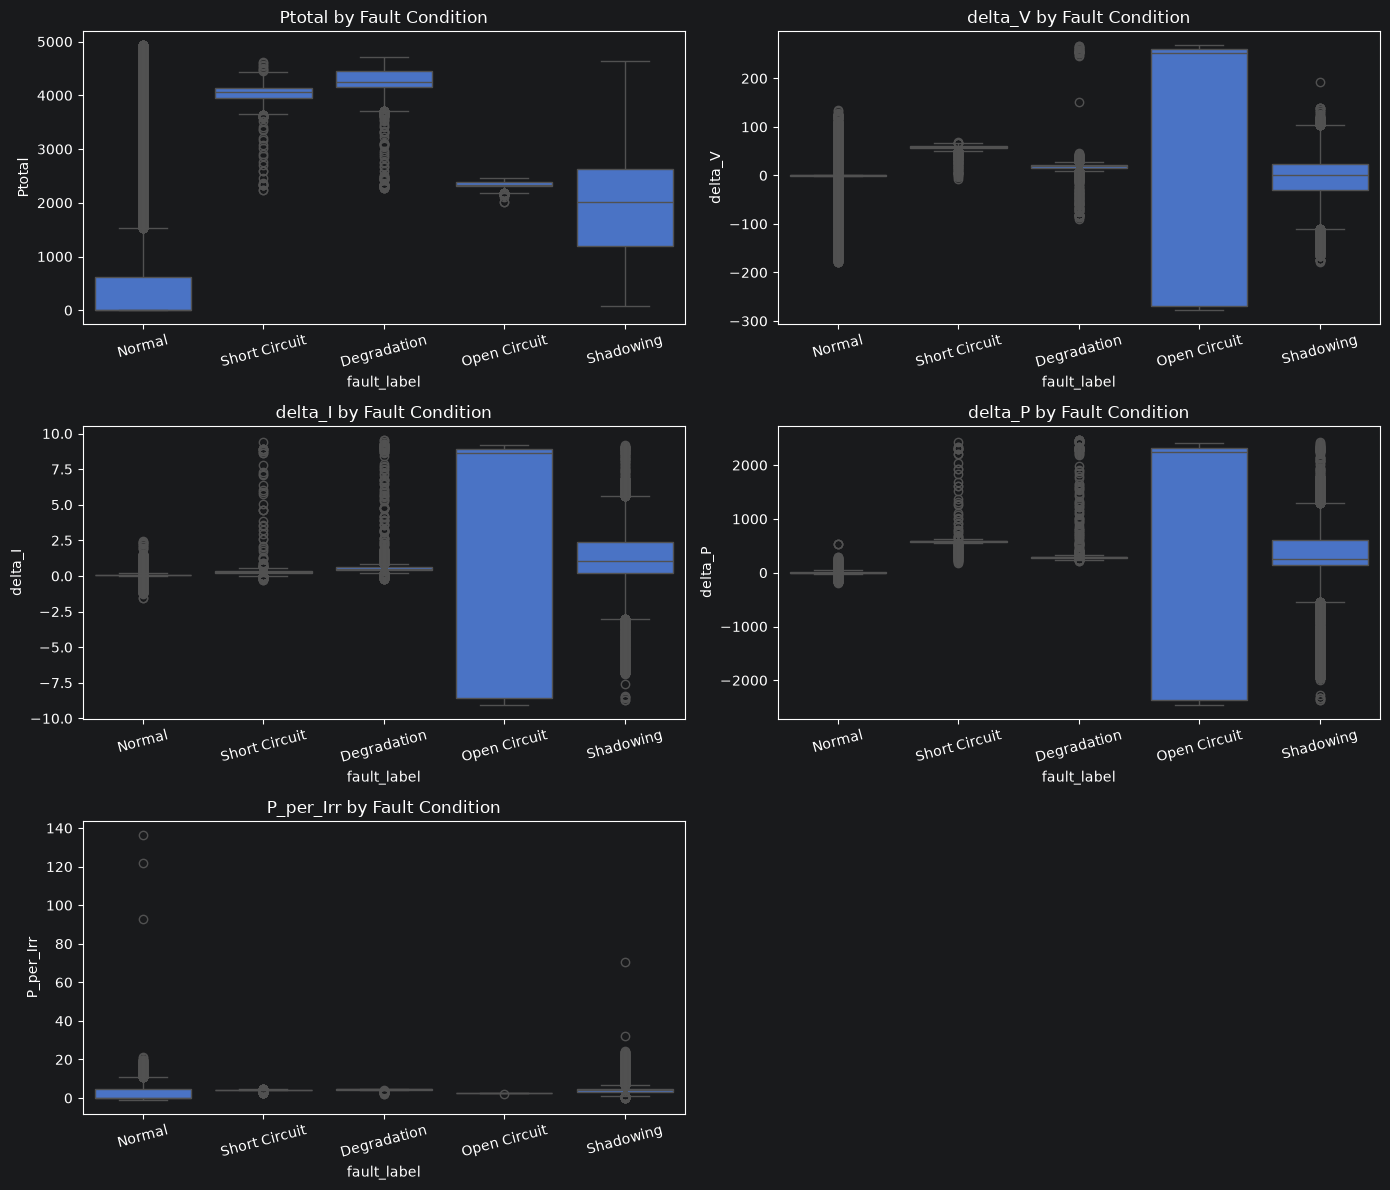

In [17]:
# for feature_engineering

import sys
sys.path.append('../src')
from feature_engineering import add_engineered_features

df = add_engineered_features(df)

new_features = ['Ptotal', 'delta_V', 'delta_I', 'delta_P', 'P_per_Irr']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    sns.boxplot(data=df, x='fault_label', y=feature, order=fault_labels.values(), ax=axes[i])
    axes[i].set_title(f'{feature} by Fault Condition')
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)  # hide the 6th empty subplot
plt.tight_layout()
plt.savefig('../reports/figures/engineered_feature_boxplots.png')
plt.show()